In [1]:
from football_dataset_xDiyoFire import *
from utils_xDiyo_wleague import *
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GCNConv, GATConv
from sklearn.metrics import precision_score, recall_score, mean_squared_error, mean_absolute_error,accuracy_score, f1_score
import matplotlib.pyplot as plt
import random
from torch.profiler import profile, ProfilerActivity
import math
from sklearn.manifold import TSNE

In [2]:
random.seed(69)
np.random.seed(69)
torch.manual_seed(69)
if torch.cuda.is_available():
    torch.cuda.manual_seed(69)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
test_names = ['Premier_League_20_21','Premier_League_21_22','Premier_League_22_23','Premier_League_23_24',
            'La_Liga_20_21','La_Liga_21_22','La_Liga_22_23','La_Liga_23_24',
            'Serie_A_20_21','Serie_A_21_22','Serie_A_22_23', 'Serie_A_23_24', 
            'Bundesliga_20_21','Bundesliga_21_22','Bundesliga_22_23', 'Bundesliga_23_24']
train_df,val_df,test_df,league_dict = split_and_merge_leagues(test_names, 0.8, 0.1, 0.1)
atk_headers,def_headers = divide_stats(stat_type='older_stats')
atk_avgs = calculate_mean_std(train_df, atk_headers)
def_avgs = calculate_mean_std(train_df, def_headers)
mu_atk,sigma_atk = extract_averages(atk_avgs, atk_headers)
mu_def,sigma_def = extract_averages(def_avgs, def_headers)
team_names = ['<PAD>']+sorted(train_df['home_team'].unique())
team2id = {name: idx for idx, name in enumerate(team_names)}


In [ ]:
# Bundle everything you want to save into a dictionary
save_cache(
    'cached_preprocessing.pkl',
    atk_headers=atk_headers,
    def_headers=def_headers,
    atk_avgs=atk_avgs,
    def_avgs=def_avgs,
    mu_atk=mu_atk,
    sigma_atk=sigma_atk,
    mu_def=mu_def,
    sigma_def=sigma_def,
    team_names=team_names,
    team2id=team2id
)

In [ ]:
cached_data = load_cache('cached_preprocessing.pkl')

atk_headers, def_headers, atk_avgs, def_avgs, mu_atk, sigma_atk, mu_def, sigma_def, team_names, team2id = cached_data['atk_headers'], cached_data['def_headers'], cached_data['atk_avgs'], cached_data['def_avgs'], 
cached_data['mu_atk'], cached_data['sigma_atk'], cached_data['mu_def'], cached_data['sigma_def'], cached_data['team_names'], cached_data['team2id']    

history_len = 8
n_x,n_y = 12,8
flatten_h, reverse_h = True, False
raw_train = FootballDataset(train_df, history_len, team2id, n_x, n_y, flatten_h, reverse_h, stat_type='older_stats')
raw_val = FootballDataset(val_df, history_len, team2id, n_x, n_y, flatten_h, reverse_h, stat_type='older_stats')
raw_test = FootballDataset(test_df, history_len, team2id, n_x, n_y, flatten_h, reverse_h, stat_type='older_stats')

In [5]:
precompute_data(raw_train, f'data/{history_len}_{n_x}_{n_y}/train', start_idx=0)
precompute_data(raw_val, f'data/{history_len}_{n_x}_{n_y}/val', start_idx=0)
precompute_data(raw_test, f'data/{history_len}_{n_x}_{n_y}/test', start_idx=0)

Preprocessed and saved sample 1/4624
Preprocessed and saved sample 2/4624
Preprocessed and saved sample 3/4624
Preprocessed and saved sample 4/4624
Preprocessed and saved sample 5/4624
Preprocessed and saved sample 6/4624
Preprocessed and saved sample 7/4624
Preprocessed and saved sample 8/4624
Preprocessed and saved sample 9/4624
Preprocessed and saved sample 10/4624
Preprocessed and saved sample 11/4624
Preprocessed and saved sample 12/4624
Preprocessed and saved sample 13/4624
Preprocessed and saved sample 14/4624
Preprocessed and saved sample 15/4624
Preprocessed and saved sample 16/4624
Preprocessed and saved sample 17/4624
Preprocessed and saved sample 18/4624
Preprocessed and saved sample 19/4624
Preprocessed and saved sample 20/4624
Preprocessed and saved sample 21/4624
Preprocessed and saved sample 22/4624
Preprocessed and saved sample 23/4624
Preprocessed and saved sample 24/4624
Preprocessed and saved sample 25/4624
Preprocessed and saved sample 26/4624
Preprocessed and save

In [22]:
# Directories for precomputed data
precomputed_dir = f'data/{history_len}_{n_x}_{n_y}'

# Build datasets from precomputed files
train_dataset = build_datasets_from_files(f'{precomputed_dir}/train')
val_dataset = build_datasets_from_files(f'{precomputed_dir}/val')
test_dataset = build_datasets_from_files(f'{precomputed_dir}/test')

# Build dataloaders
batch_size = 1024
train_loader = build_train_loader(train_dataset, batch_size=batch_size)
val_loader = build_val_loader(val_dataset, batch_size=batch_size)
test_loader = build_test_loader(test_dataset, batch_size=batch_size)

In [23]:
data_iter = iter(test_loader)
batch_data = next(data_iter)
edges = extract_edge_info(train_dataset)

c:\Users\luisi\Documents\Programming\Python\Football\xDiyo\football_dataset_xDiyoFire.py:1247: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(self.file_path

In [16]:
class CreateEmbMLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=None, num_layers=1, dropout=0.0, bias=None):
        super().__init__()
        self.num_layers = num_layers
        if num_layers == 1:
            final_layer = nn.Linear(input_dim, output_dim)
            if bias is not None:
                # Expecting bias to be a tensor of shape (output_dim,)
                if bias.shape != final_layer.bias.shape:
                    raise ValueError(f"Bias tensor shape mismatch. Expected {final_layer.bias.shape}, got {bias.shape}")
                final_layer.bias.data.copy_(bias)
            self.layers = final_layer
        else:
            hidden_dim = hidden_dim if hidden_dim is not None else input_dim
            net = []
            # First layer
            net.append(nn.Linear(input_dim, hidden_dim))
            net.append(nn.ReLU())
            if dropout > 0:
                net.append(nn.Dropout(dropout))
            # Hidden layers
            for _ in range(num_layers - 2):
                net.append(nn.Linear(hidden_dim, hidden_dim))
                net.append(nn.ReLU())
                if dropout > 0:
                    net.append(nn.Dropout(dropout))
            # Final output layer
            final_layer = nn.Linear(hidden_dim, output_dim)
            if bias is not None:
                if bias.shape != final_layer.bias.shape:
                    raise ValueError(f"Bias tensor shape mismatch. Expected {final_layer.bias.shape}, got {bias.shape}")
                final_layer.bias.data.copy_(bias)
            net.append(final_layer)
            self.layers = nn.Sequential(*net)

    def forward(self, x):
        return self.layers(x)
    

class TeamGAT(nn.Module):
    def __init__(self, num_teams, input_dim, hidden_dim, num_heads=2, num_layers=2, dropout=0.1):
        super().__init__()
        
        # GAT layers
        self.gat_layers = nn.ModuleList()
        self.gat_layers.append(GATConv(input_dim, hidden_dim, heads=num_heads, dropout=dropout))
        
        for _ in range(num_layers - 1):
            self.gat_layers.append(GATConv(hidden_dim * num_heads, hidden_dim, heads=num_heads, dropout=dropout))
        
        self.out_linear = nn.Linear(hidden_dim * num_heads, input_dim)
    
    def forward(self, x, edge_index):
        # Get node features (team embeddings)
        edge_index = edge_index.to(x.device)
        
        # Apply GAT layers
        for gat in self.gat_layers:
            x = gat(x, edge_index)
            x = torch.relu(x)
        
        # Project back to input_dim (optional)
        x = self.out_linear(x)
        
        return x


class TeamEmbedding(nn.Module):
    def __init__(self, embed_dim, num_teams, mu_sigma, pad_idx=0, stats_hidden_dim=None, 
                coupled=False, device='cuda', training_embeds=True,gnn_hidden_dim=32, gnn_layers=1,standardize = True):
        """
        Args:
            embed_dim: Dimensionality of the team embedding.
            num_teams: Number of teams.
            mu_sigma: Tuple (mu_atk, sigma_atk, mu_def, sigma_def).
            pad_idx: Padding index for the embedding.
            stats_hidden_dim: Hidden dimension for the prediction MLP.
            coupled: If True, uses a coupled prediction branch.
            device: Device string.
            training_embeds: If True, uses only the last row of the sequence (for training);
                            if False, applies the transformations to the entire sequence.
        """
        super(TeamEmbedding, self).__init__()
        self.device = device
        self.training_embeds = training_embeds
        self.standardize = standardize
        self.mu_atk, self.sigma_atk, self.mu_def, self.sigma_def = mu_sigma

        self.mu_atk = self.mu_atk.to(self.device)
        self.sigma_atk = self.sigma_atk.to(self.device)
        self.mu_def = self.mu_def.to(self.device)
        self.sigma_def = self.sigma_def.to(self.device)
        self.stats_dim = len(self.mu_atk[0]) + len(self.mu_def[0])

        self.coupled = coupled

        # Embedding layer
        # Initial team embeddings (could use pretrained or learned embeddings)
        self.embedding = nn.Embedding(num_teams, embed_dim, padding_idx=pad_idx)
        # Standard team embeddings are trained with an MLP
        self.team_gat = TeamGAT(num_teams=num_teams, input_dim=embed_dim, hidden_dim=gnn_hidden_dim, num_heads=2,
                                num_layers = gnn_layers, dropout=0.1)
        
        # Embedding training module
        self.feat_extraction = CreateEmbMLP(embed_dim+2+96, self.stats_dim, hidden_dim=stats_hidden_dim,
                                            num_layers=5, dropout=0.0)

        # Prediction module (MLP)
        if self.coupled:
            self.prediction = CreateEmbMLP((embed_dim + 2+96)*2, 2*self.stats_dim,
                                        hidden_dim=stats_hidden_dim, num_layers=5,
                                        dropout=0.0)
        else:
            self.prediction = CreateEmbMLP(embed_dim + 2, self.stats_dim,
                                        hidden_dim=stats_hidden_dim, num_layers=3,
                                        dropout=0.0)

    def forward(self, batch,edge_index, key=None):
        if self.standardize:
            batch = standardize_stats(batch, self.mu_atk, self.sigma_atk, self.mu_def, self.sigma_def)
        batch_size = batch['home_team_atk'].shape[0]
        edge_index.to(self.device)
        

        # Obtain masks and lengths for both teams.
        valid_home_mask = batch['home_team_valid_mask']
        valid_away_mask = batch['away_team_valid_mask']
        home_scores_lengths = batch['home_team_scores_lengths'].to('cpu')
        away_scores_lengths = batch['away_team_scores_lengths'].to('cpu')

        if self.training_embeds:
            # Use only the last row of each sequence.
            home_team_atk = batch['home_team_atk'][:,-1:,:]
            home_team_def = batch['home_team_def'][:,-1:,:]
            away_team_atk = batch['away_team_atk'][:,-1:,:]
            away_team_def = batch['away_team_def'][:,-1:,:]

            home_team_is_home = batch['home_team_is_home'][:,-1:]
            home_team_standings = batch['home_team_standings'][:,-1:]
            home_team_heatmap = batch['home_team_player_heatmap_sequence'][:,-1:,:]
            away_team_is_home = batch['away_team_is_home'][:,-1:]
            away_team_standings = batch['away_team_standings'][:,-1:]
            away_team_heatmap = batch['away_team_player_heatmap_sequence'][:,-1:,:]
            
            # Stacking
            home_away_is_home = torch.cat([home_team_is_home, away_team_is_home], dim=0)
            home_away_standings = torch.cat([home_team_standings, away_team_standings], dim=0)
            home_away_heatmap = torch.cat([home_team_heatmap, away_team_heatmap], dim=0)

            home_team_indexes = batch['home_team_index'][:,-1:]
            away_team_indexes = batch['away_team_index'][:,-1:]
            home_team_league = batch['leagues'][:]
            away_team_league = batch['leagues'][:]
            
            home_team_embed = self.embedding(home_team_indexes)
            away_team_embed = self.embedding(away_team_indexes)
            home_away_embed = torch.cat([home_team_embed, away_team_embed], dim=0)
            
            
            # We pass the embeddings too to the GAT module
            updated_team_embeds = self.team_gat(self.embedding.weight, edge_index)  # shape: (num_teams, embed_dim)
            # Look up updated embeddings for the teams from the GNN.
            home_team_gat = updated_team_embeds[home_team_indexes]
            away_team_gat = updated_team_embeds[away_team_indexes]
            
            home_team_names = [name for names in batch['home_team_names'] for name in names[-1:]]
            away_team_names = [name for names in batch['away_team_names'] for name in names[-1:]]
            
            # Combine indexes and names.
            all_indexes = torch.cat([home_team_indexes, away_team_indexes], dim=0)
            all_names = home_team_names + away_team_names
            all_leagues = torch.cat([home_team_league, away_team_league], dim=0)
            
            
            # Combine attack and defense stats.
            home_stats = torch.cat([home_team_atk, home_team_def], dim=-1)
            away_stats = torch.cat([away_team_atk, away_team_def], dim=-1)
            labels = torch.cat([home_stats, away_stats], dim=0)
            labels = labels.squeeze(1)  # when using last row, squeeze the second dimension
        else:
            1+1
            # Use the entire sequence.
            #team_atk = batch[f'{key}_team_atk']      # shape: (B, seq_len, dim)
            #team_def = batch[f'{key}_team_def']
            #enemy_atk = batch[f'{key}_enemy_atk']
            #enemy_def = batch[f'{key}_enemy_def']

            #team_is_home = batch[f'{key}_team_is_home']  # shape: (B, seq_len, 1)
            #team_standings = batch[f'{key}_team_standings']
            #enemy_is_home = batch[f'{key}_enemy_is_home']
            #enemy_standings = batch[f'{key}_enemy_standings']

            # For indexes and names, assume that the whole sequence is provided;
            # You might decide to aggregate these (e.g. using the last element or a mean) for downstream usage.
            # Here we simply use the entire sequence for further processing.
            #team_indexes = batch[f'{key}_team_index']
            #enemy_indexes = batch[f'{key}_enemy_index']
            # For team names, we assume each sample contains a list of names (one per match)
            # and we take the last name in the sequence (or you might choose to do something else).
            #team_names = batch[f'{key}_team_names']
            #enemy_names = batch[f'{key}_enemy_names']
            
            #team_embed = self.embedding_layer(team_indexes)
            #enemy_embed = self.embedding_layer(enemy_indexes)
        
        #if self.training_embeds:
        #    labels = labels.squeeze(1)  # when using last row, squeeze the second dimension

        # Predict stats from embeddings.
        if self.coupled:
            
            if self.training_embeds:
                home_away_stats = torch.cat([home_away_embed, home_away_heatmap, home_away_is_home, home_away_standings], dim=-1)
                home_away_features = self.feat_extraction(home_away_stats).squeeze(1)
                
                home_away_input = torch.cat([home_team_gat, home_team_heatmap, home_team_is_home, home_team_standings,
                                        away_team_gat, away_team_heatmap, away_team_is_home, away_team_standings], dim=-1)
                predicted_stats = self.prediction(home_away_input)
                home_stats_pred = predicted_stats[..., :self.stats_dim]
                away_stats_pred = predicted_stats[..., self.stats_dim:]
                home_away_stats = torch.cat([home_stats_pred, away_stats_pred], dim=0).squeeze(1)
                
            else:
                1+1
                #home_away_input = torch.cat([team_embed, team_is_home, team_standings,
                #                        enemy_embed, enemy_is_home, enemy_standings], dim=-1)
                #predicted_stats = self.prediction(home_away_input)
                # When coupled, split predictions.
                #if key == 'home':
                #    valid_mask = valid_home_mask
                #else:
                #    valid_mask = valid_away_mask
                #team_pred = predicted_stats[..., :self.stats_dim]*valid_mask
                #enemy_pred = predicted_stats[..., self.stats_dim:]*valid_mask
                #
                #return team_embed,enemy_embed, team_pred, enemy_pred
        
        
        else:
            1+1
            #home_away_input = torch.cat([home_team_embed, home_team_is_home, home_team_standings,
            #                            away_team_embed, away_team_is_home, away_team_standings], dim=-1)
            #home_away_stats = self.prediction(home_away_input)

        return labels, home_away_stats, home_away_features, all_indexes, all_names, home_away_embed, all_leagues

    def _embeds_only(self, indexes):
        return self.embedding_layer(indexes)


    
        
        


In [17]:
def train_autoencoder(model, train_loader, valid_loader, device, lr=1e-4, epochs=10):
    """
    Trains the model (autoencoder) using MSE loss.

    The model's forward should return a tuple:
        (labels, predicted_stats, all_indexes, all_names, all_teams_embed)
    where:
        - labels: Ground truth stats (Tensor)
        - predicted_stats: The reconstructed stats (Tensor)
    
    Args:
        model: Your autoencoder model (e.g., TeamEmbedding).
        train_loader: DataLoader for training samples.
        valid_loader: DataLoader for validation samples.
        device: The device to use ('cuda' or 'cpu').
        lr: Learning rate.
        epochs: Number of training epochs.

    Returns:
        (train_losses, valid_losses): Lists of average loss per epoch.
    """
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0

        for batch in train_loader:
            # Move all tensor data in the batch to the target device.
            for key in batch:
                if torch.is_tensor(batch[key]):
                    batch[key] = batch[key].to(device)
            
            optimizer.zero_grad()
            # Forward pass: get labels and reconstructed stats.
            labels, predicted_stats, extracted_features, all_indexes, all_names, all_teams_embed,_ = model(batch)
            rep_loss = criterion(extracted_features, labels)
            match_loss = criterion(predicted_stats, labels)
            loss = rep_loss + match_loss
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * predicted_stats.size(0)
        
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        model.eval()
        running_valid_loss = 0.0
        with torch.no_grad():
            for batch in valid_loader:
                for key in batch:
                    if torch.is_tensor(batch[key]):
                        batch[key] = batch[key].to(device)
                
                labels, predicted_stats, extracted_features, all_indexes, all_names, all_teams_embed,_ = model(batch)
                rep_loss = criterion(extracted_features, labels)
                match_loss = criterion(predicted_stats, labels)
                loss = rep_loss + match_loss
                running_valid_loss += loss.item() * predicted_stats.size(0)
        
        epoch_valid_loss = running_valid_loss / len(valid_loader.dataset)
        valid_losses.append(epoch_valid_loss)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_train_loss:.4f} | Valid Loss: {epoch_valid_loss:.4f}")
    
    return train_losses, valid_losses

def plot_losses(train_losses, valid_losses):
    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, valid_losses, label="Valid Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Train vs. Validation Loss")
    plt.legend()
    plt.show()

class AsymmetricLoss(nn.Module):
    def __init__(self, weight_over=2.0, weight_under=1.0):
        super().__init__()
        self.weight_over = weight_over
        self.weight_under = weight_under
        
    def forward(self, preds, targets):
        diff = preds - targets
        loss = torch.where(diff >= 0,
                           self.weight_over * diff.pow(2),
                           self.weight_under * diff.pow(2))
        return loss.mean()

# Use in training:
#criterion = AsymmetricLoss(weight_over=2.0, weight_under=1.0)


# Example usage:
# train_losses, valid_losses = train_autoencoder(model, train_loader, valid_loader, device='cuda', lr=1e-4, epochs=20)


In [ ]:
torch.save(test_embedder.state_dict(), 'embeddings_128hid_1gnn_2heads_reluleagues_nocards.pth')

In [18]:
mu_sigma = (mu_atk, sigma_atk, mu_def, sigma_def)
embed_dim = 128
gnn_hidden_dim = 128
gnn_layers = 1
stats_hidden_dim = 256

test_embedder = TeamEmbedding(embed_dim, num_teams=len(team2id), mu_sigma=mu_sigma,pad_idx=0,
                            stats_hidden_dim=None, coupled=True, device='cuda', training_embeds=True,
                            gnn_hidden_dim=gnn_hidden_dim, gnn_layers=gnn_layers)
#embedding_state = torch.load('embeddings_tanh_5_layers_test.pth')
#test_embedder.load_state_dict(embedding_state)

In [ ]:
embed_state = torch.load('embeddings_32hid_1gnn_2heads.pth')
test_embedder.load_state_dict(embed_state)

In [19]:
import torch
import torch.nn as nn

def train_autoencoder_tweaked(model, train_loader, valid_loader, device, lr=1e-4, epochs=10, patience=5,
                    scheduler_factor=0.5, scheduler_patience=2):
    """
    Trains the model (autoencoder) using MSE loss with early stopping and a learning rate scheduler.
    
    The model's forward should return a tuple:
        (labels, predicted_stats, all_indexes, all_names, all_teams_embed)
    where:
        - labels: Ground truth stats (Tensor)
        - predicted_stats: The reconstructed stats (Tensor)
    
    Args:
        model: Your autoencoder model (e.g., TeamEmbedding).
        train_loader: DataLoader for training samples.
        valid_loader: DataLoader for validation samples.
        device: The device to use ('cuda' or 'cpu').
        lr: Learning rate.
        epochs: Maximum number of training epochs.
        patience: Number of epochs to wait for improvement in validation loss before stopping.
        scheduler_factor: Factor by which to reduce the learning rate.
        scheduler_patience: Number of epochs with no improvement after which LR is reduced.
    
    Returns:
        (train_losses, valid_losses): Lists of average loss per epoch (up to early stopping).
    """
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    #criterion = nn.SmoothL1Loss(beta=0.15) 
    #criterion = AsymmetricLoss(weight_over=2.0, weight_under=1.0)

    # Set up a learning rate scheduler that reduces LR when validation loss plateaus.
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                        factor=scheduler_factor, 
                                                        patience=scheduler_patience, 
                                                        verbose=True)
    
    train_losses = []
    valid_losses = []
    match_losses = []

    best_valid_loss = float('inf')
    patience_counter = 0
    best_epoch = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0

        for batch in train_loader:
            # Move all tensor data in the batch to the target device.
            for key in batch:
                if torch.is_tensor(batch[key]):
                    batch[key] = batch[key].to(device)
            
            optimizer.zero_grad()
            # Forward pass: get labels and reconstructed stats.
            labels, predicted_stats, extracted_features, all_indexes, all_names, all_teams_embed,_ = model(batch,edges)
            rep_loss = criterion(extracted_features, labels)
            match_loss = criterion(predicted_stats, labels)
            loss = 0.5*rep_loss + match_loss
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * predicted_stats.size(0)
        
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        model.eval()
        running_valid_loss = 0.0
        running_match_loss = 0.0
        with torch.no_grad():
            for batch in valid_loader:
                for key in batch:
                    if torch.is_tensor(batch[key]):
                        batch[key] = batch[key].to(device)
                
                labels, predicted_stats, extracted_features, all_indexes, all_names, all_teams_embed,_ = model(batch,edges)
                rep_loss = criterion(extracted_features, labels)
                match_loss = criterion(predicted_stats, labels)
                loss = 0.2 *rep_loss + match_loss
                running_valid_loss += loss.item() * predicted_stats.size(0)
                running_match_loss += match_loss.item() * predicted_stats.size(0)
                
        
        epoch_valid_loss = running_valid_loss / len(valid_loader.dataset)
        epoch_match_loss = running_match_loss / len(valid_loader.dataset)
        valid_losses.append(epoch_valid_loss)
        match_losses.append(epoch_match_loss)
        

        # Step the scheduler with the validation loss.
        scheduler.step(epoch_valid_loss)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_train_loss:.4f} | Valid Loss: {epoch_valid_loss:.4f} | Match Loss: {epoch_match_loss:.4f}")

        # Early stopping check.
        if epoch_valid_loss < best_valid_loss:
            best_valid_loss = epoch_valid_loss
            best_epoch = epoch
            patience_counter = 0
            best_model_state = model.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}. Best validation loss: {best_valid_loss:.4f} at epoch {best_epoch+1}.")
                break

    # Optionally, load the best model state.
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return train_losses, valid_losses, match_losses 

# Example usage:
# train_losses, valid_losses = train_autoencoder(model, train_loader, valid_loader, device='cuda', lr=1e-4, epochs=20, patience=5)


In [91]:
torch.save(test_embedder.state_dict(), 'embeddings_128hid_1gnn_2heads_reluleagues_nocards.pth')

In [20]:
train_losses, valid_losses, match_losses = train_autoencoder_tweaked(test_embedder, train_loader, val_loader, device='cuda',
                                                        lr=1e-3, epochs=100, patience=5,
                                                        scheduler_factor=0.1, scheduler_patience=2)

c:\Users\luisi\Documents\Programming\Python\Market\market_env\Lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/100 - Train Loss: 2.9893 | Valid Loss: 2.4308 | Match Loss: 2.0267
Epoch 2/100 - Train Loss: 2.9630 | Valid Loss: 2.4007 | Match Loss: 2.0085
Epoch 3/100 - Train Loss: 2.9175 | Valid Loss: 2.3554 | Match Loss: 1.9733
Epoch 4/100 - Train Loss: 2.8553 | Valid Loss: 2.2868 | Match Loss: 1.9095
Epoch 5/100 - Train Loss: 2.7979 | Valid Loss: 2.2531 | Match Loss: 1.8765
Epoch 6/100 - Train Loss: 2.7592 | Valid Loss: 2.2237 | Match Loss: 1.8480
Epoch 7/100 - Train Loss: 2.7296 | Valid Loss: 2.1870 | Match Loss: 1.8130
Epoch 8/100 - Train Loss: 2.7010 | Valid Loss: 2.1569 | Match Loss: 1.7828
Epoch 9/100 - Train Loss: 2.6657 | Valid Loss: 2.1347 | Match Loss: 1.7619
Epoch 10/100 - Train Loss: 2.6397 | Valid Loss: 2.1093 | Match Loss: 1.7390
Epoch 11/100 - Train Loss: 2.6135 | Valid Loss: 2.0945 | Match Loss: 1.7253
Epoch 12/100 - Train Loss: 2.5953 | Valid Loss: 2.0874 | Match Loss: 1.7191
Epoch 13/100 - Train Loss: 2.5829 | Valid Loss: 2.0711 | Match Loss: 1.7035
Epoch 14/100 - Train 

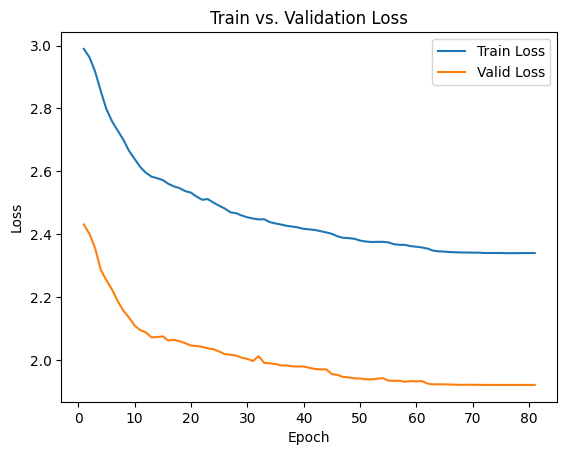

In [21]:
plot_losses(train_losses, valid_losses)

In [30]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize_embeddings(model, test_loader, device='cuda'):
    """
    Visualize team embeddings from the test dataloader using t-SNE.
    
    The model's forward is assumed to return a tuple:
         (labels, predicted_stats, team_ids, names, embeddings)
    where:
         - embeddings: Tensor of shape (batch_size, d) or (batch_size, 1, d)
         - team_ids:   Tensor of shape (batch_size,) with team IDs
         - names:      A list of team names for each sample in the batch
         
    Only one embedding per unique team is selected globally (across all batches).
    """
    model.eval()
    all_embeddings = []
    all_team_ids = []  # list of team IDs (as Python ints)
    all_names = []     # corresponding team names

    with torch.no_grad():
        for batch in test_loader:
            # Move tensors in the batch to the target device.
            for key in batch:
                if torch.is_tensor(batch[key]):
                    batch[key] = batch[key].to(device)
            # Assume model returns: (labels, predicted_stats, team_ids, names, embeddings)
            _, _,_, team_ids, names, embeddings,_ = model(batch,edges)
            team_ids = team_ids.squeeze().cpu().tolist()  # ensure team_ids is a list of scalars
            all_team_ids.extend(team_ids)
            all_names.extend(names)
            all_embeddings.append(embeddings.cpu().numpy())

    # Concatenate embeddings from all batches.
    all_embeddings = np.concatenate(all_embeddings, axis=0)
    
    # If embeddings have an extra singleton dimension (e.g. shape (batch_size, 1, d)), squeeze it.
    if all_embeddings.ndim == 3 and all_embeddings.shape[1] == 1:
        all_embeddings = np.squeeze(all_embeddings, axis=1)
    
    # Select one embedding per unique team globally.
    unique_embeddings = []
    unique_team_ids = []
    unique_names = []
    seen = set()
    for i, tid in enumerate(all_team_ids):
        if tid not in seen:
            seen.add(tid)
            # Squeeze the embedding in case it has an extra dimension.
            unique_embeddings.append(np.squeeze(all_embeddings[i]))
            unique_team_ids.append(tid)
            unique_names.append(all_names[i])
    unique_embeddings = np.array(unique_embeddings)

    # Apply t-SNE to reduce dimensions to 2.
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    tsne_results = tsne.fit_transform(unique_embeddings)

    # Plot the t-SNE result.
    plt.figure(figsize=(10, 8))
    plt.scatter(tsne_results[:, 0], tsne_results[:, 1], s=10, alpha=0.7, c='blue')

    # Annotate each unique team point with its name.
    for i, name in enumerate(unique_names):
        plt.annotate(name, (tsne_results[i, 0], tsne_results[i, 1]),
                     fontsize=10, alpha=0.75)

    plt.title("t-SNE Visualization of Unique Team Embeddings")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.tight_layout()
    plt.show()

# Example usage:
# visualize_embeddings(test_embedder, test_loader, device='cuda')


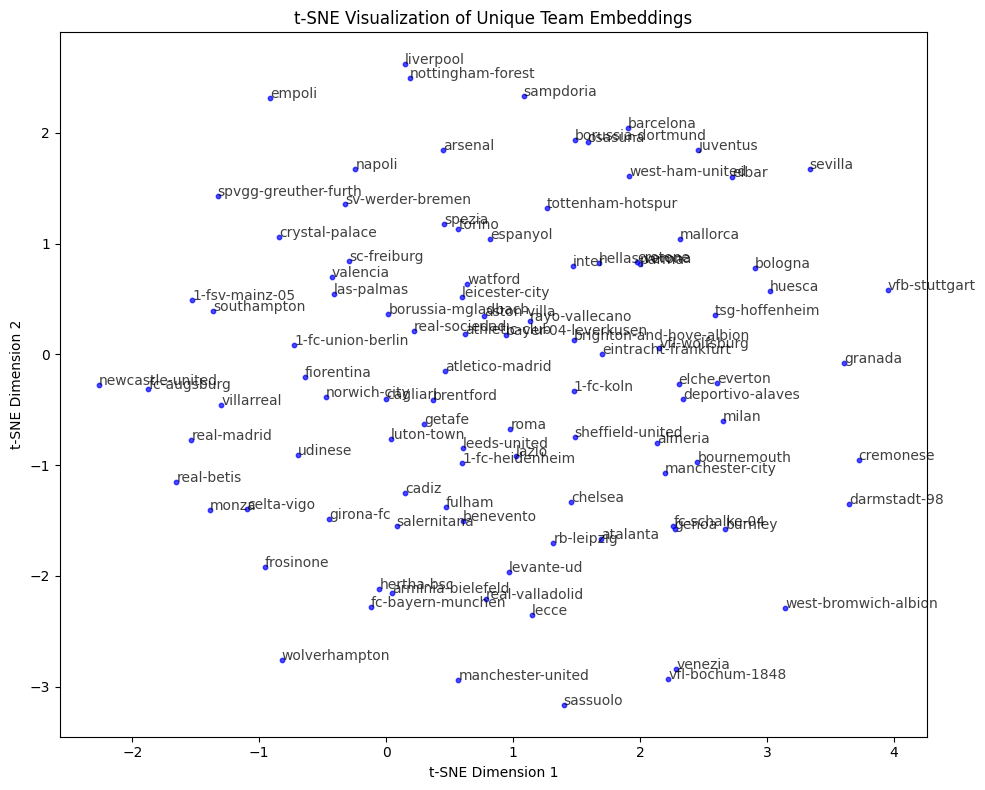

In [31]:
visualize_embeddings(test_embedder, test_loader, device='cuda')

In [55]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

def visualize_embeddings(model, test_loader, device='cuda'):
    """
    Visualize team embeddings from the test dataloader using t-SNE after centering and scaling.

    The model's forward is assumed to return a tuple:
        (labels, predicted_stats, team_ids, names, embeddings)
    where:
        - embeddings: Tensor of shape (batch_size, d) or (batch_size, 1, d)
        - team_ids:   Tensor of shape (batch_size,) with team IDs
        - names:      A list of team names for each sample in the batch
        
    Only one embedding per unique team is selected globally (across all batches).
    """
    model.eval()
    all_embeddings = []
    all_team_ids = []  # list of team IDs (as Python ints)
    all_names = []     # corresponding team names

    with torch.no_grad():
        for batch in test_loader:
            # Move tensors in the batch to the target device.
            for key in batch:
                if torch.is_tensor(batch[key]):
                    batch[key] = batch[key].to(device)
            # Assume model returns: (labels, predicted_stats, team_ids, names, embeddings)
            _, _,_, team_ids, names, embeddings,_ = model(batch,edges)
            team_ids = team_ids.squeeze().cpu().tolist()  # ensure team_ids is a list of scalars
            all_team_ids.extend(team_ids)
            all_names.extend(names)
            all_embeddings.append(embeddings.cpu().numpy())

    # Concatenate embeddings from all batches.
    all_embeddings = np.concatenate(all_embeddings, axis=0)
    
    # If embeddings have an extra singleton dimension (e.g. shape (batch_size, 1, d)), squeeze it.
    if all_embeddings.ndim == 3 and all_embeddings.shape[1] == 1:
        all_embeddings = np.squeeze(all_embeddings, axis=1)
    
    # Select one embedding per unique team globally.
    unique_embeddings = []
    unique_team_ids = []
    unique_names = []
    seen = set()
    for i, tid in enumerate(all_team_ids):
        if tid not in seen:
            seen.add(tid)
            # Squeeze the embedding in case it has an extra dimension.
            unique_embeddings.append(np.squeeze(all_embeddings[i]))
            unique_team_ids.append(tid)
            unique_names.append(all_names[i])
    unique_embeddings = np.array(unique_embeddings)

    # Center and scale the embeddings before applying t-SNE.
    scaler = StandardScaler()
    unique_embeddings = scaler.fit_transform(unique_embeddings)

    # Apply t-SNE to reduce dimensions to 2.
    tsne = TSNE(n_components=2, perplexity=2.5, random_state=42)
    tsne_results = tsne.fit_transform(unique_embeddings)

    # Plot the t-SNE result.
    plt.figure(figsize=(10, 8))
    plt.scatter(tsne_results[:, 0], tsne_results[:, 1], s=50, alpha=0.7, c='blue')

    # Annotate each unique team point with its name.
    for i, name in enumerate(unique_names):
        plt.annotate(name, (tsne_results[i, 0], tsne_results[i, 1]),
                     fontsize=10, alpha=0.75)

    plt.title("t-SNE Visualization of Unique Team Embeddings (Centered & Scaled)")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.tight_layout()
    plt.show()

# Example usage:
# visualize_embeddings(test_embedder, test_loader, device='cuda')


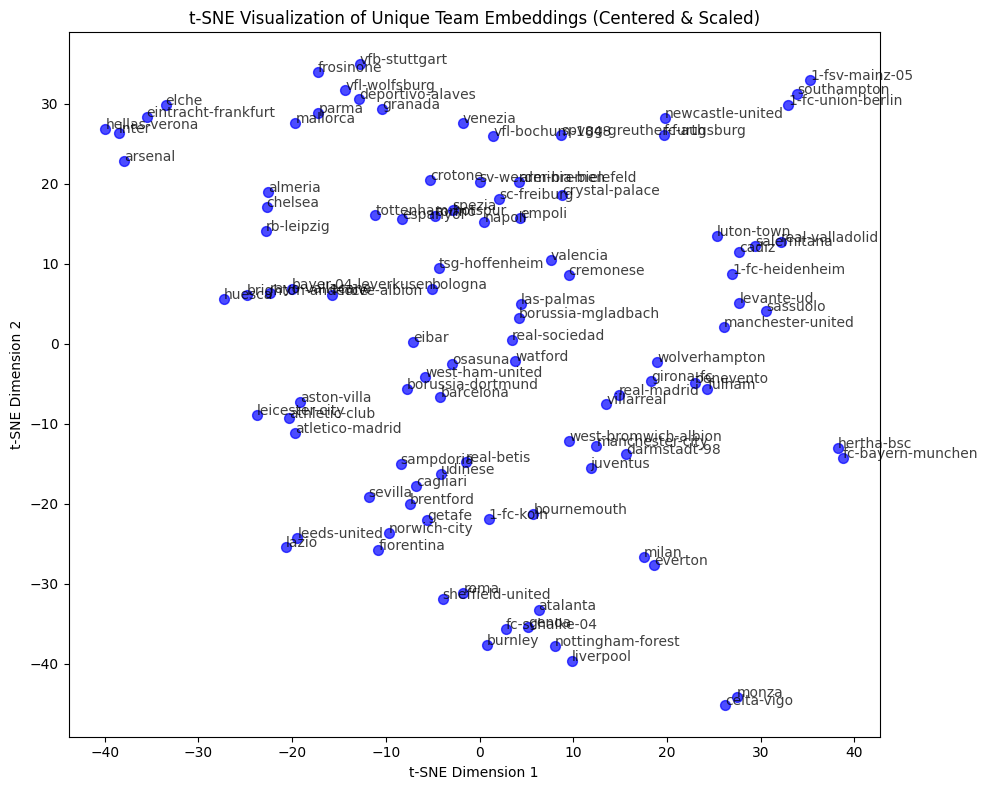

In [56]:
test_embedder.to('cuda')
visualize_embeddings(test_embedder, test_loader, device='cuda')

In [34]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def visualize_embeddings_pca(model, test_loader, device='cuda', component_x=0, component_y=1):
    """
    Visualize team embeddings from the test dataloader using PCA.
    
    The model's forward is assumed to return a tuple:
        (labels, predicted_stats, team_ids, names, embeddings)
    where:
        - embeddings: Tensor of shape (batch_size, d) or (batch_size, 1, d)
        - team_ids:   Tensor of shape (batch_size,) with team IDs
        - names:      A list of team names for each sample in the batch
        
    Only one embedding per unique team is selected globally (across all batches).
    
    Parameters:
        model: The model from which to extract embeddings.
        test_loader: DataLoader providing test data.
        device: Device on which to run computations ('cuda' or 'cpu').
        component_x: Index of the PCA component to use for the x-axis (0-indexed).
        component_y: Index of the PCA component to use for the y-axis (0-indexed).
    """
    model.eval()
    all_embeddings = []
    all_team_ids = []  # list of team IDs (as Python ints)
    all_names = []     # corresponding team names

    with torch.no_grad():
        for batch in test_loader:
            # Move each tensor in the batch to the specified device.
            for key in batch:
                if torch.is_tensor(batch[key]):
                    batch[key] = batch[key].to(device)
            # Assume model returns: (labels, predicted_stats, team_ids, names, embeddings)
            _, _,_, team_ids, names, embeddings,_ = model(batch,edges)
            # Squeeze team_ids so that we get scalars, then convert to list.
            team_ids = team_ids.squeeze().cpu().tolist()
            all_team_ids.extend(team_ids)
            all_names.extend(names)
            all_embeddings.append(embeddings.cpu().numpy())

    # Concatenate embeddings from all batches.
    all_embeddings = np.concatenate(all_embeddings, axis=0)
    
    # If embeddings have an extra singleton dimension (shape (N,1,d)), squeeze it.
    if all_embeddings.ndim == 3 and all_embeddings.shape[1] == 1:
        all_embeddings = np.squeeze(all_embeddings, axis=1)
    
    # Select one embedding per unique team globally.
    unique_embeddings = []
    unique_team_ids = []
    unique_names = []
    seen = set()
    for i, tid in enumerate(all_team_ids):
        if tid not in seen:
            seen.add(tid)
            unique_embeddings.append(all_embeddings[i])
            unique_team_ids.append(tid)
            unique_names.append(all_names[i])
    unique_embeddings = np.array(unique_embeddings)

    # Ensure PCA computes enough components.
    n_components = max(component_x, component_y) + 1
    pca = PCA(n_components=n_components)
    pca_results = pca.fit_transform(unique_embeddings)

    # Extract the chosen components for visualization.
    x_vals = pca_results[:, component_x]
    y_vals = pca_results[:, component_y]

    # Plot the PCA results.
    plt.figure(figsize=(10, 8))
    plt.scatter(x_vals, y_vals, s=50, alpha=0.7, c='blue')

    # Annotate each unique team point with its name.
    for i, name in enumerate(unique_names):
        plt.annotate(name, (x_vals[i], y_vals[i]), fontsize=10, alpha=0.75)

    plt.title("PCA Visualization of Unique Team Embeddings")
    plt.xlabel(f"PCA Component {component_x + 1}")
    plt.ylabel(f"PCA Component {component_y + 1}")
    plt.tight_layout()
    plt.show()

# Example usage:
# visualize_embeddings_pca(test_embedder, test_loader, device='cuda', component_x=0, component_y=1)


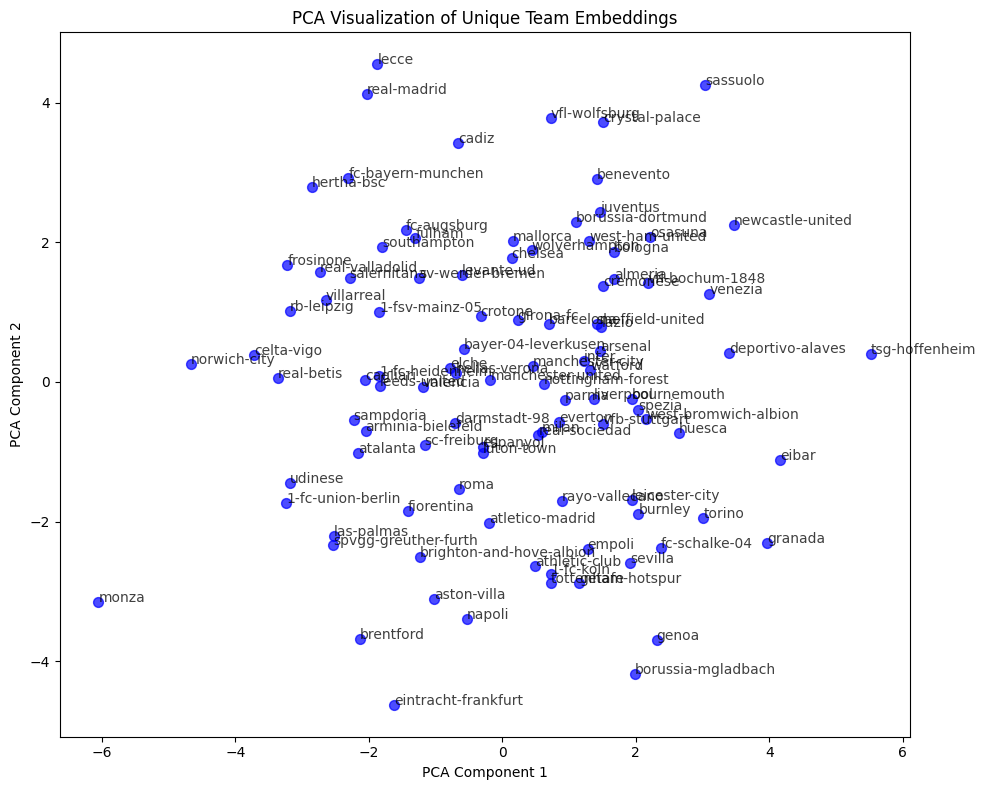

In [37]:
visualize_embeddings_pca(test_embedder, test_loader, device='cuda', component_x=0, component_y=1)

In [44]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def visualize_embeddings_pca(model, test_loader, device='cuda', component_x=0, component_y=1):
    """
    Visualize team embeddings from the test dataloader using PCA after centering and scaling.
    
    The model's forward is assumed to return a tuple:
         (labels, predicted_stats, team_ids, names, embeddings)
    where:
         - embeddings: Tensor of shape (batch_size, d) or (batch_size, 1, d)
         - team_ids:   Tensor of shape (batch_size,) with team IDs
         - names:      A list of team names for each sample in the batch
         
    Only one embedding per unique team is selected globally (across all batches).
    
    Parameters:
        model: The model from which to extract embeddings.
        test_loader: DataLoader providing test data.
        device: Device on which to run computations ('cuda' or 'cpu').
        component_x: Index of the PCA component to use for the x-axis (0-indexed).
        component_y: Index of the PCA component to use for the y-axis (0-indexed).
    """
    model.eval()
    all_embeddings = []
    all_team_ids = []  # list of team IDs (as Python ints)
    all_names = []     # corresponding team names

    with torch.no_grad():
        for batch in test_loader:
            # Move each tensor in the batch to the specified device.
            for key in batch:
                if torch.is_tensor(batch[key]):
                    batch[key] = batch[key].to(device)
            # Assume model returns: (labels, predicted_stats, team_ids, names, embeddings)
            _, _,_, team_ids, names, embeddings,_ = model(batch,edges)
            # Squeeze team_ids so that we get scalars, then convert to list.
            team_ids = team_ids.squeeze().cpu().tolist()
            all_team_ids.extend(team_ids)
            all_names.extend(names)
            all_embeddings.append(embeddings.cpu().numpy())

    # Concatenate embeddings from all batches.
    all_embeddings = np.concatenate(all_embeddings, axis=0)
    
    # If embeddings have an extra singleton dimension (shape (N,1,d)), squeeze it.
    if all_embeddings.ndim == 3 and all_embeddings.shape[1] == 1:
        all_embeddings = np.squeeze(all_embeddings, axis=1)
    
    # Select one embedding per unique team globally.
    unique_embeddings = []
    unique_team_ids = []
    unique_names = []
    seen = set()
    for i, tid in enumerate(all_team_ids):
        if tid not in seen:
            seen.add(tid)
            unique_embeddings.append(all_embeddings[i])
            unique_team_ids.append(tid)
            unique_names.append(all_names[i])
    unique_embeddings = np.array(unique_embeddings)

    # Center and scale the embeddings before applying PCA.
    scaler = StandardScaler()
    unique_embeddings = scaler.fit_transform(unique_embeddings)

    # Ensure PCA computes enough components.
    n_components = max(component_x, component_y) + 1
    pca = PCA(n_components=n_components)
    pca_results = pca.fit_transform(unique_embeddings)

    # Extract the chosen components for visualization.
    x_vals = pca_results[:, component_x]
    y_vals = pca_results[:, component_y]

    # Plot the PCA results.
    plt.figure(figsize=(10, 8))
    plt.scatter(x_vals, y_vals, s=50, alpha=0.7, c='blue')

    # Annotate each unique team point with its name.
    for i, name in enumerate(unique_names):
        plt.annotate(name, (x_vals[i], y_vals[i]), fontsize=10, alpha=0.75)

    plt.title("PCA Visualization of Unique Team Embeddings (Centered & Scaled)")
    plt.xlabel(f"PCA Component {component_x + 1}")
    plt.ylabel(f"PCA Component {component_y + 1}")
    plt.tight_layout()
    plt.show()

# Example usage:
# visualize_embeddings_pca(test_embedder, test_loader, device='cuda', component_x=0, component_y=1)


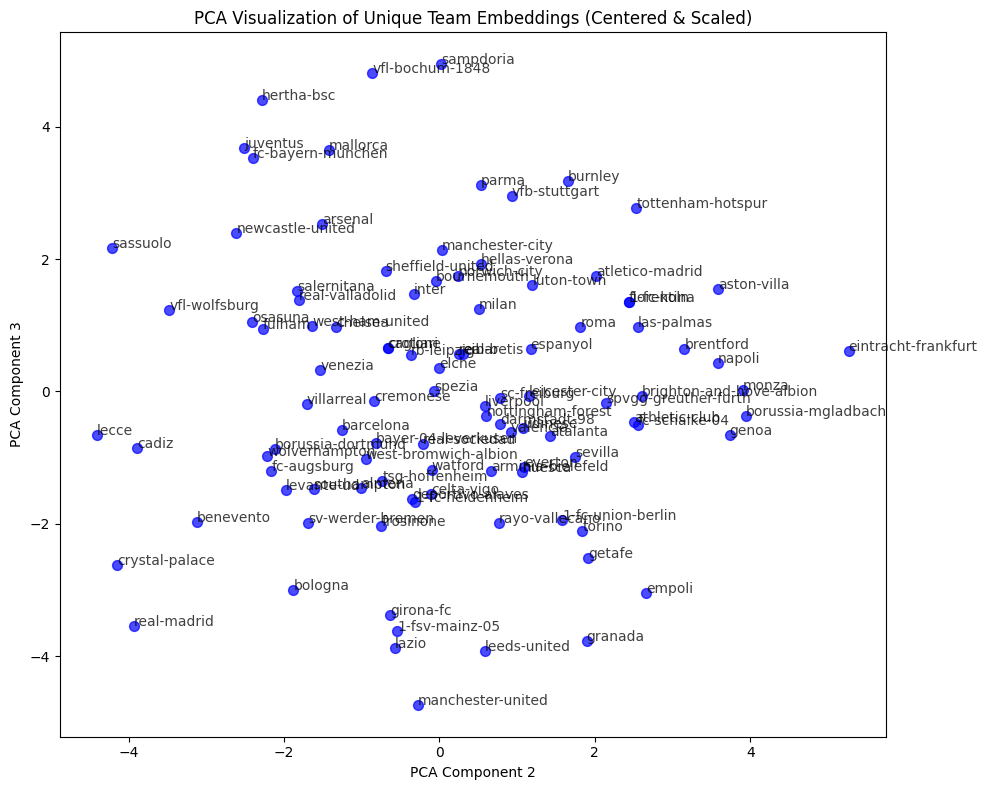

In [48]:
visualize_embeddings_pca(test_embedder, test_loader, device='cuda', component_x=1, component_y=2)

In [19]:
def test_embedding_equality_by_name(model, test_loader, device='cuda', atol=1e-6, rtol=1e-5):
    """
    For each unique team name in the test_loader, check whether all embeddings
    (returned by the model) for that team are equal (using torch.allclose).

    The model's forward is assumed to return a tuple:
         (_, team_ids, names, embeddings)
    where:
         - names: a list of team names (one per sample)
         - embeddings: Tensor of shape (batch_size, d)

    Args:
        model: The model (e.g., your TeamEmbedding module).
        test_loader: DataLoader for the test set.
        device: Device string.
        atol, rtol: Tolerances for torch.allclose.
    """
    model.eval()
    all_embeddings = []
    all_names = []  # list of team names

    with torch.no_grad():
        for batch in test_loader:
            for key in batch:
                if torch.is_tensor(batch[key]):
                    batch[key] = batch[key].to(device)
            # Assume model returns: (_, team_ids, names, embeddings)
            _,_, team_ids, names, embeddings = model(batch)
            all_names.extend(names)
            all_embeddings.append(embeddings.cpu())

    # Concatenate all embeddings along the batch dimension.
    all_embeddings = torch.cat(all_embeddings, dim=0)
    
    # Ensure the names list matches the number of embeddings.
    n_points = all_embeddings.shape[0]
    all_names = all_names[:n_points]

    # Group embeddings by team name.
    name_to_embeds = {}
    for i, name in enumerate(all_names):
        if name not in name_to_embeds:
            name_to_embeds[name] = []
        name_to_embeds[name].append(all_embeddings[i])

    # Check equality within each group.
    for name, embeds in name_to_embeds.items():
        if len(embeds) < 2:
            print(f"Team '{name}': Only one instance, skipping.")
        else:
            base = embeds[0]
            equal = all(torch.allclose(emb, base, atol=atol, rtol=rtol) for emb in embeds[1:])
            if equal:
                print(f"Team '{name}': Equal")
            else:
                print(f"Team '{name}': Not Equal")

# Example usage:
# test_embedding_equality_by_name(test_embedder, test_loader, device='cuda')


In [ ]:
test_embedding_equality_by_name(test_embedder, test_loader, device='cuda')

In [24]:
test_embedder.to('cuda')
for key in batch_data:
                if torch.is_tensor(batch_data[key]):
                    batch_data[key] = batch_data[key].to('cuda')
labels_t, home_away_stats_t,_, all_indexes_t, all_names_t, all_teams_embed_t, all_leagues_t= test_embedder(batch_data,edges)

In [ ]:
test_embedder.to('cuda')
for key in batch_data:
    if torch.is_tensor(batch_data[key]):
        batch_data[key] = batch_data[key].to('cuda')
team_embed,enemy_embed,team_pred, enemy_pred= test_embedder(batch_data, edges)

In [17]:
reference_t=torch.cat([mu_atk, mu_def], dim=0).to('cuda')
sigma_t = torch.cat([sigma_atk, sigma_def], dim=0).to('cuda')  

In [167]:
test_ind = 106
torch.set_printoptions(sci_mode=False) 
((home_away_stats_t[test_ind]*sigma_t)-(labels_t[test_ind]*sigma_t))[4]

tensor(1.0578, device='cuda:0', dtype=torch.float64, grad_fn=<SelectBackward0>)

In [168]:
((home_away_stats_t[test_ind]*sigma_t)+reference_t)[4]

tensor(4.0578, device='cuda:0', dtype=torch.float64, grad_fn=<SelectBackward0>)

In [25]:
b_size = home_away_stats_t.shape[0]//2
home_away_stats_t =inverse_standardize_stats(home_away_stats_t, all_leagues_t, mu_atk, sigma_atk, mu_def, sigma_def)
home_corners = home_away_stats_t[:b_size,4]
away_corners = home_away_stats_t[b_size:,4]
home_names = all_names_t[:b_size]
away_names = all_names_t[b_size:]
labels_t = inverse_standardize_stats(labels_t, all_leagues_t, mu_atk, sigma_atk, mu_def, sigma_def)
home_labels = labels_t[:b_size,4]
away_labels = labels_t[b_size:,4]
all_corners = home_corners+away_corners
all_labels = home_labels+away_labels

In [26]:
# Define header with fixed-width columns.
header = (
    f"{'Home Name':<25} {'Home Predicted':<15} {'Home Corners':<15} "
    f"{'Away Name':<25} {'Away Predicted':<15} {'Away Corners':<15} "
    f"{'All Predicted':<15} {'All Corners':<15}"
)
print(header)
print("-" * len(header))

# Print each row with float values truncated to 2 decimal places.
for i in range(len(all_corners)):
    row = (
        f"{home_names[i]:<25} "
        f"{home_corners[i]:<15.2f} "
        f"{home_labels[i]:<15.2f} "
        f"{away_names[i]:<25} "
        f"{away_corners[i]:<15.2f} "
        f"{away_labels[i]:<15.2f} "
        f"{all_corners[i]:<15.2f} "
        f"{all_labels[i]:<15.2f}"
    )
    print(row)

Home Name                 Home Predicted  Home Corners    Away Name                 Away Predicted  Away Corners    All Predicted   All Corners    
---------------------------------------------------------------------------------------------------------------------------------------------------
sheffield-united          3.78            5.00            crystal-palace            6.35            11.00           10.13           16.00          
manchester-city           5.32            6.00            chelsea                   3.70            2.00            9.02            8.00           
newcastle-united          2.90            4.00            manchester-city           8.31            5.00            11.21           9.00           
west-ham-united           5.70            9.00            leeds-united              4.51            5.00            10.21           14.00          
brighton-and-hove-albion  9.15            4.00            southampton               2.05            3.00        

In [208]:
all_corners = ((home_away_stats_t*sigma_t)-(labels_t*sigma_t))

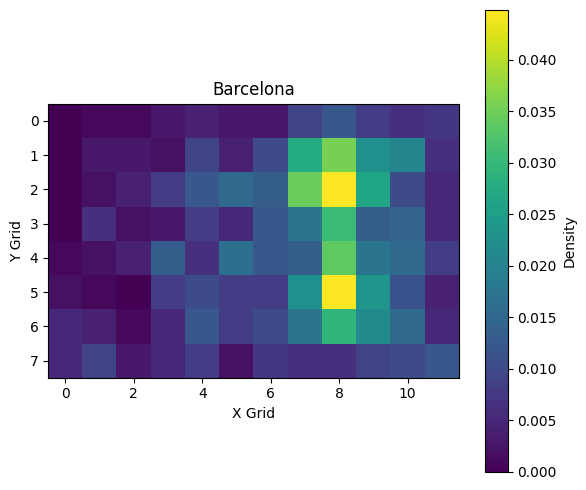

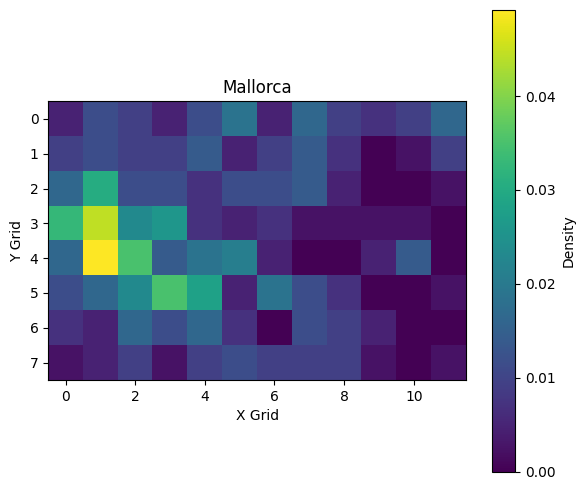

In [65]:
barc_tensor=batch_data['home_team_player_heatmap_sequence'][169][-1].to('cpu')
mallorc_tensor = batch_data['away_team_player_heatmap_sequence'][169][-1].to('cpu')
plot_heatmap(barc_tensor, n_x, n_y, title="Barcelona", cmap='viridis')
plot_heatmap(mallorc_tensor, n_x, n_y, title="Mallorca", cmap='viridis')


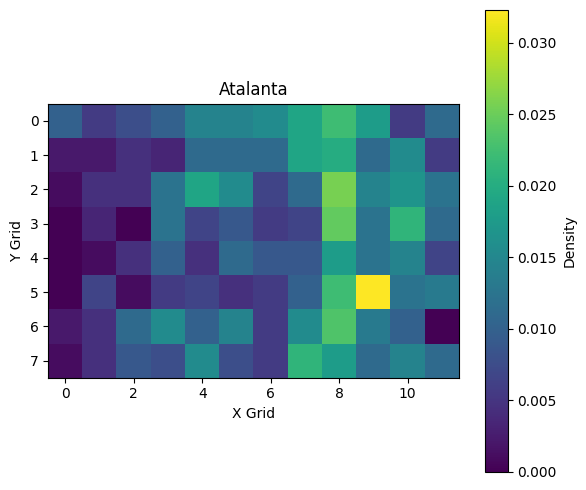

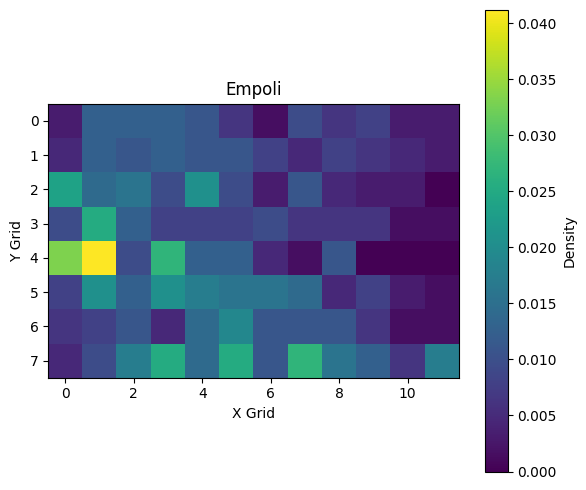

In [69]:
at_tensor=batch_data['home_team_player_heatmap_sequence'][304][-1].to('cpu')
emp_tensor = batch_data['away_team_player_heatmap_sequence'][304][-1].to('cpu')
plot_heatmap(at_tensor, n_x, n_y, title="Atalanta", cmap='viridis')
plot_heatmap(emp_tensor, n_x, n_y, title="Empoli", cmap='viridis')

In [47]:
all_header = atk_headers+def_headers

In [230]:
all_corners+reference_t[4]

tensor([4.6118, 5.4113, 4.4523, 5.2212, 4.9733, 5.3938, 4.8966, 4.1953, 6.3226,
        5.4458, 5.0289, 5.9411, 5.6215, 5.6062, 5.0750, 5.3168, 6.0348, 4.4520,
        5.6333, 4.2576, 4.4681, 6.0291, 5.4989, 5.9907, 5.2679, 4.7032, 6.9758,
        3.9163, 5.0758, 5.8295, 4.4718, 5.1754, 4.9147, 5.2021, 5.9532, 6.1699,
        5.4196, 5.9455, 5.7886, 6.1349, 5.6308, 5.0655, 4.9023, 5.0211, 4.5153,
        6.7641, 4.3193, 4.9660, 4.8832, 4.3297, 4.4025, 6.2827, 6.1314, 6.3160,
        4.2777, 5.1416, 5.0656, 4.1736, 5.5302, 4.7645, 4.0977, 5.1043, 4.4344,
        4.6618, 4.8279, 5.0801, 5.3226, 4.2578, 5.4125, 4.2856, 4.7657, 3.4875,
        3.8591, 5.1210, 3.3665, 4.6437, 4.5085, 4.9406, 4.1983, 5.6370, 3.9894,
        5.1450, 4.5118, 4.8712, 4.2061, 4.4299, 5.4453, 6.4958, 3.7942, 4.8878,
        6.0674, 4.9445, 5.3617, 4.8071, 3.8094, 3.8481, 3.5113, 4.4305, 5.2017,
        5.2601, 2.9400, 4.2560, 3.1837, 6.3428, 4.8175, 4.1234, 4.3711, 4.2523,
        5.9110, 4.6732, 4.9491, 4.9371, 

In [91]:
all_names_t

['sheffield-united',
 'manchester-city',
 'newcastle-united',
 'west-ham-united',
 'brighton-and-hove-albion',
 'manchester-city',
 'newcastle-united',
 'arsenal',
 'aston-villa',
 'brentford',
 'chelsea',
 'crystal-palace',
 'everton',
 'burnley',
 'leeds-united',
 'leicester-city',
 'manchester-united',
 'southampton',
 'manchester-united',
 'newcastle-united',
 'wolverhampton',
 'everton',
 'aston-villa',
 'bournemouth',
 'southampton',
 'tottenham-hotspur',
 'nottingham-forest',
 'luton-town',
 'arsenal',
 'brentford',
 'burnley',
 'sheffield-united',
 'manchester-city',
 'brighton-and-hove-albion',
 'chelsea',
 'brighton-and-hove-albion',
 'liverpool',
 'crystal-palace',
 'fulham',
 'bournemouth',
 'everton',
 'newcastle-united',
 'tottenham-hotspur',
 'west-ham-united',
 'wolverhampton',
 'nottingham-forest',
 'crystal-palace',
 'manchester-united',
 'aston-villa',
 'arsenal',
 'brentford',
 'brighton-and-hove-albion',
 'burnley',
 'chelsea',
 'crystal-palace',
 'liverpool',
 'lu

In [158]:
[i for i in range(len(all_names_t)) if all_names_t[i]=='burnley']   

[13, 30, 52, 82, 106]

In [80]:
all_header = atk_headers+def_headers
all_header[51]

'total_yellowcards'

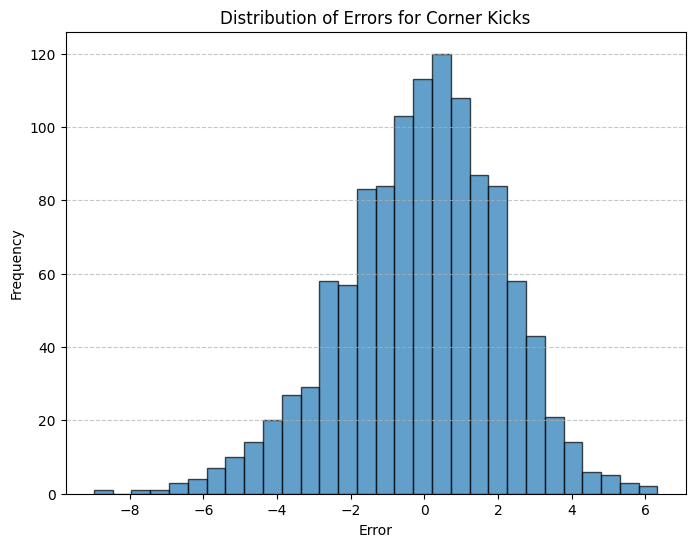

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Compute the errors for the entire batch, move to CPU, detach, and convert to numpy
errors = [home_away_stats_t[i].cpu().detach()[4]- 
          labels_t[i].cpu().detach()[4] for i in range(len(labels_t))]

# Convert list of tensors to NumPy and flatten them
errors = np.concatenate([e.numpy().flatten() for e in errors])

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(errors, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.title('Distribution of Errors for Corner Kicks')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



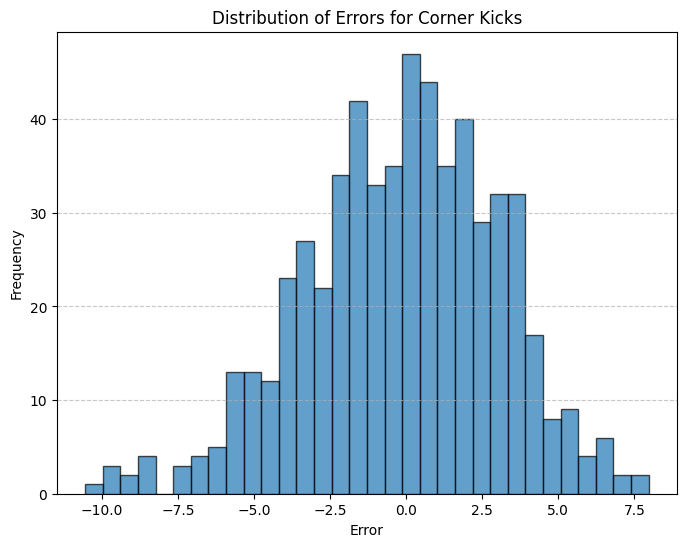

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Compute the errors for the entire batch, move to CPU, detach, and convert to numpy
errors = [(all_corners[i].cpu().detach() - 
        all_labels[i].cpu().detach()) for i in range(len(all_labels))]

# Convert list of tensors to NumPy and flatten them
errors = np.concatenate([e.numpy().flatten() for e in errors])

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(errors, bins=32, edgecolor='black', alpha=0.7)
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.title('Distribution of Errors for Corner Kicks')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
6,14,25,57,69,99,119

In [183]:
all_names_t[119]

'wolverhampton'

In [17]:

new_test = standardize_stats(batch_data, mu_atk, sigma_atk, mu_def, sigma_def)

In [21]:
new_test['home_team_def'].shape

torch.Size([583, 9, 30])

In [15]:
batch_data['home_team_player_heatmap_sequence'][:,-1:,:].shape

torch.Size([583, 1, 96])